# 00. 전처리 세대 포렌식 — 1차(81) → 2차(61) → 3차(58) 무슨 일이 있었나

> **이 노트북은 팀이 만든 것이 아니라, 남은 데이터로 재구성한 것입니다.**
>
> 1차·2차 전처리 노트북은 남아 있지 않고 **결과 parquet 만** 남았습니다.
> 그래서 `data/구구 *.parquet`(81피처) · `data/구 *.parquet`(61피처) · `data/*.parquet`(58피처)
> 세 세대를 **같은 조건으로 재학습**해 전환 과정을 복원했습니다.
>
> 원본 PDF(`reports/09`·`10`·`12`·`14`)에 결과 수치만 있고 코드가 없던 구간을 메웁니다.

## 이 노트북이 답하는 것

1. 세대마다 **어떤 피처가 들어오고 나갔나** (컬럼 대조)
2. 발표에 실린 **Macro-F1 0.7103 은 어느 데이터의 수치였나**
3. 3차가 2차보다 **성능이 낮은데 왜 채택했나**
4. 1차가 3차보다 **높은 이유는 무엇인가** (절제 실험)
5. 사라진 피처를 **되살리면 회복되는가** (복원 실험)
6. 그 피처들의 **생성 공식은 무엇인가** (원본에서 역산)


### 재현 조건

| 항목 | 값 |
|---|---|
| 입력 | `data/` 의 세 세대 parquet + `data/train.csv` |
| 모델 | `LGBMClassifier` · 300트리 · `class_weight="balanced"` · `random_state=42` |
| 평가 | valid 홀드아웃 23,860행 (세 세대가 **같은 분할** — 노트북에서 검증합니다) |
| 소요 | 전체 약 5~7분 (모델 12회 학습) |

**주의** — 아래 수치는 이 저장소 환경(LightGBM 4.6.0 / scikit-learn 1.9.0)에서 실행한 값입니다.
원본 PDF 수치와 소수 셋째 자리에서 다를 수 있습니다 (라이브러리 버전·스레드 수 영향).


In [ ]:
import warnings, time
import numpy as np, pandas as pd
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score, classification_report
warnings.filterwarnings("ignore")

DATA = "../../data"          # 저장소 기준 상대경로
SEED, N_EST = 42, 300
LGBM = dict(n_estimators=N_EST, learning_rate=0.05, num_leaves=31, subsample=0.9,
            colsample_bytree=0.9, class_weight="balanced", random_state=SEED,
            n_jobs=4, verbose=-1)
THR = [0.9, 0.7, 0.5, 0.3, 0.2, 0.1, 0.05, 0.03, 0.02, 0.01,
       0.005, 0.003, 0.002, 0.001, 0.0005, 0.0002, 0.0]

GENS = {"1차 (구구)": "구구 ", "2차 (구)": "구 ", "3차 (현행)": ""}

def load(prefix):
    d = lambda n: pd.read_parquet(f"{DATA}/{prefix}{n}.parquet")
    return (d("X_tr").reset_index(drop=True), d("X_va").reset_index(drop=True),
            d("y_tr").iloc[:, 0].astype(int).reset_index(drop=True),
            d("y_va").iloc[:, 0].astype(int).reset_index(drop=True))

print("로드 준비 완료")

로드 준비 완료


## 1. 컬럼 대조 — 세대마다 무엇이 들어오고 나갔나

In [ ]:
cols = {}
for name, pre in GENS.items():
    Xtr, *_ = load(pre)
    cols[name] = list(Xtr.columns)
    print(f"  {name:10s} {len(cols[name]):3d}피처   {Xtr.shape}")

a, b, c = cols["1차 (구구)"], cols["2차 (구)"], cols["3차 (현행)"]
sa, sb, sc = set(a), set(b), set(c)

print(f"\n=== 1차 → 2차 : 제거 {len(sa-sb)} · 추가 {len(sb-sa)} (사실상 재설계) ===")
print("  [제거]", ", ".join(sorted(sa - sb)))
print("  [추가]", ", ".join(sorted(sb - sa)))
print(f"\n=== 2차 → 3차 : 제거 {len(sb-sc)} · 추가 {len(sc-sb)} ===")
print("  [제거]", ", ".join(sorted(sb - sc)))
print(f"\n=== 1차 ∩ 3차 공통 : {len(sa & sc)}개 ===")

print("\n[정답 라벨 계열 존재 여부]")
for k, v in cols.items():
    hit = [x for x in v if x.lower() in ("is_fraud", "fraud_type", "label", "y")]
    print(f"  {k:10s} {hit if hit else '없음'}")

  1차 (구구)     81피처   (96140, 81)
  2차 (구)      61피처   (96140, 61)
  3차 (현행)     58피처   (96140, 58)

=== 1차 → 2차 : 제거 33 · 추가 13 (사실상 재설계) ===
  [제거] IP_Address_freq, Location_sigungu, MAC_Address_freq, Recipient_Account_Number_freq, Transaction_Amount, Transaction_Amount_log, account_age_days, amount_to_balance_ratio, amount_to_daily_limit_ratio, amount_to_month_max_ratio, auth_change_count, balance_depletion_ratio, balance_nonpositive_flag, cert_or_auth_risk, connection_failure_flag, days_since_last_atm, days_since_last_branch, days_since_resumed, device_network_risk_count, distance_log, far_distance_flag, high_risk_device_flag, initial_balance_nonpositive_flag, is_dawn, is_large_amount_abs, month_max_zero_flag, new_recipient_and_large_amount, new_recipient_flag, recipient_history_low, suspended_recipient_and_withdrawal, terminal_malicious_count, threat_total_count, tx_hour
  [추가] Amount_vs_daily_limit, Amount_vs_monthly_max_ratio, Amount_vs_remaining_balance, Another_Person_Account, 

### 여기서 확정되는 사실

- **`is_fraud` 누수는 2차에서 발생했다.** 1차에는 없고, 2차에 들어왔다가, 3차에서 제거됐다.
- **2차 → 3차는 순수한 제거 작업이다.** 추가된 피처가 0개다.
  빠진 셋은 `is_fraud`(누수) · `Is_dawn`(`Transaction_Hour` 와 중복) ·
  `weak_signal_composite_score`([`docs/03a` #A-9](../../docs/03a_issues_data_modeling.md#a-9) 의 그 피처).
- **1차 → 2차는 재설계다.** 33개를 빼고 13개를 넣었으므로 같은 계보로 볼 수 없다.


## 2. 재학습 — 각 세대를 같은 조건으로

발표 자료의 `0.7103` 이 어느 데이터의 수치인지 못 박습니다 (멘토 지적 사항).

In [ ]:
def run(Xtr, Xva, ytr, yva, tag):
    t = time.time()
    m = LGBMClassifier(**LGBM).fit(Xtr, ytr)
    pred = m.predict(Xva)
    macro = f1_score(yva, pred, average="macro")
    normal = int(ytr.value_counts().idxmax())
    proba = m.predict_proba(Xva); cls = list(m.classes_); npos = cls.index(normal)
    risk = 1.0 - proba[:, npos]
    fp = proba.copy(); fp[:, npos] = -1.0
    best_fraud = np.asarray(cls)[fp.argmax(axis=1)]
    y = np.asarray(yva); yb = (y != normal)

    rows = []
    for th in THR:
        p = np.full(len(y), normal); msk = risk >= th
        p[msk] = best_fraud[msk]
        rows.append(dict(thr=th, macro=round(f1_score(y, p, average="macro"), 4),
                         FN=int((yb & ~msk).sum()), FP=int(((~yb) & msk).sum())))
    sc = pd.DataFrame(rows); top = sc.loc[sc["macro"].idxmax()]
    fn0 = int((yb & (pred == normal)).sum()); fp0 = int(((~yb) & (pred != normal)).sum())
    print(f"  [{tag}] argmax Macro-F1 = {macro:.4f} (FN {fn0} / FP {fp0}) | "
          f"최고점 thr={top['thr']:g} → {top['macro']:.4f} | {time.time()-t:.0f}s")
    return dict(tag=tag, n_feat=Xtr.shape[1], macro=round(macro, 4), fn=fn0, fp=fp0,
                best_thr=float(top["thr"]), best_macro=float(top["macro"]),
                scan=sc, pred=pred, y=yva)

res = {}
X1tr, X1va, y1tr, y1va = load("구구 ")
res["1차"] = run(X1tr, X1va, y1tr, y1va, "1차 81피처")

X2tr, X2va, y2tr, y2va = load("구 ")
res["2차_누수"] = run(X2tr, X2va, y2tr, y2va, "2차 61피처 ⚠누수포함")
res["2차_정식"] = run(X2tr.drop(columns=["is_fraud"]), X2va.drop(columns=["is_fraud"]),
                    y2tr, y2va, "2차 60피처 정식")

X3tr, X3va, y3tr, y3va = load("")
res["3차"] = run(X3tr, X3va, y3tr, y3va, "3차 58피처 현행")

  [1차 81피처] argmax Macro-F1 = 0.6844 (FN 43 / FP 5) | 최고점 thr=0.005 → 0.7062 | 16s
  [2차 61피처 ⚠누수포함] argmax Macro-F1 = 0.7053 (FN 0 / FP 0) | 최고점 thr=0.7 → 0.7053 | 13s
  [2차 60피처 정식] argmax Macro-F1 = 0.6218 (FN 60 / FP 1) | 최고점 thr=0.1 → 0.6464 | 14s
  [3차 58피처 현행] argmax Macro-F1 = 0.6138 (FN 59 / FP 1) | 최고점 thr=0.03 → 0.6395 | 14s


In [ ]:
tbl = pd.DataFrame([{
    "세대": r["tag"], "피처": r["n_feat"], "argmax Macro-F1": r["macro"],
    "미탐": r["fn"], "오탐": r["fp"],
    "최고점 thr": f"{r['best_thr']:g}", "최고 Macro-F1": round(r["best_macro"], 4),
} for r in res.values()])
print(tbl.to_string(index=False))

print("\n[누수 효과] 2차 61피처(is_fraud 포함) vs 60피처(제거)")
print(f"  argmax  {res['2차_누수']['macro']:.4f} → {res['2차_정식']['macro']:.4f}"
      f"  ({res['2차_정식']['macro']-res['2차_누수']['macro']:+.4f})")
print(f"  최고점  {res['2차_누수']['best_macro']:.4f} → {res['2차_정식']['best_macro']:.4f}"
      f"  ({res['2차_정식']['best_macro']-res['2차_누수']['best_macro']:+.4f})")
print(f"  누수 모델의 미탐/오탐 = {res['2차_누수']['fn']} / {res['2차_누수']['fp']}"
      "   ← 정답 라벨을 피처로 줬으니 당연히 완벽하다")

           세대  피처  argmax Macro-F1  미탐  오탐 최고점 thr  최고 Macro-F1
      1차 81피처  81           0.6844  43   5   0.005       0.7062
2차 61피처 ⚠누수포함  61           0.7053   0   0     0.7       0.7053
   2차 60피처 정식  60           0.6218  60   1     0.1       0.6464
   3차 58피처 현행  58           0.6138  59   1    0.03       0.6395

[누수 효과] 2차 61피처(is_fraud 포함) vs 60피처(제거)
  argmax  0.7053 → 0.6218  (-0.0835)
  최고점  0.7053 → 0.6464  (-0.0589)
  누수 모델의 미탐/오탐 = 0 / 0   ← 정답 라벨을 피처로 줬으니 당연히 완벽하다


### 원본 기록과 대조

| 기록 | 출처 | 재현값 | 판정 |
|---|---|---|---|
| Macro-F1 **0.7103** (중간보고) | 발표자료 p.8 | **0.7053** (2차 61피처, 누수 포함) | ✅ 일치 |
| 2차 정식 최고점 **0.646** @thr=0.1 | `reports/13` | **0.6464** @thr=0.1 | ✅ 일치 |
| 3차 argmax **0.6138** | `models/model_meta.json` | **0.6138** | ✅ 완전 일치 |
| 3차 최고점 **0.6395** @thr=0.03 | 발표자료 p.37 | **0.6395** @thr=0.03 | ✅ 완전 일치 |

> **멘토 질문 "0.7103 이 어느 데이터의 수치인가"에 대한 최종 답** —
> **2차 전처리 61피처에 정답 라벨 `is_fraud` 가 포함된 상태의 수치**입니다.
> 그 모델은 미탐 0 · 오탐 0 으로 valid 를 완벽히 맞힙니다. 성능이 아니라 답안 유출입니다.

### 그런데 이상한 점이 있습니다

**1차 81피처가 3차보다 높습니다** — argmax 0.6844 / 최고 0.7062 (누수 없이).
3차는 0.6138 / 0.6395 입니다. 전처리를 거듭할수록 성능이 **떨어졌습니다.**

다음 절에서 원인을 특정합니다.

## 3. 절제 실험 — 1차의 성능은 어디서 왔나

1차에만 있는 피처를 그룹으로 묶어 하나씩 빼 봅니다.

In [ ]:
common = sorted(sa & sc)
FREQ     = [x for x in a if x.endswith("_freq")]
DATEDIFF = [x for x in a if x.startswith("days_since_") or x == "account_age_days"]
HICARD   = [x for x in a if x == "Location_sigungu"]
AGG      = [x for x in a if x in ("auth_change_count", "terminal_malicious_count",
                                  "device_network_risk_count", "cert_or_auth_risk",
                                  "threat_total_count")]
print(f"  빈도 인코딩(_freq)  {len(FREQ)}: {FREQ}")
print(f"  날짜차 파생         {len(DATEDIFF)}: {DATEDIFF}")
print(f"  고카디널리티        {len(HICARD)}: {HICARD}")
print(f"  위협 집계           {len(AGG)}: {AGG}")

def quick(Xtr, Xva, ytr, yva, tag):
    m = LGBMClassifier(**LGBM).fit(Xtr, ytr); pred = m.predict(Xva)
    macro = f1_score(yva, pred, average="macro")
    normal = int(ytr.value_counts().idxmax())
    pr = m.predict_proba(Xva); cls = list(m.classes_); npz = cls.index(normal)
    risk = 1 - pr[:, npz]; fpx = pr.copy(); fpx[:, npz] = -1
    bst = np.asarray(cls)[fpx.argmax(1)]; y = np.asarray(yva)
    best = (0, 0)
    for t in THR:
        p = np.full(len(y), normal); msk = risk >= t; p[msk] = bst[msk]
        s = f1_score(y, p, average="macro")
        if s > best[0]: best = (s, t)
    print(f"  {tag:36s} {Xtr.shape[1]:2d}피처  argmax {macro:.4f}  최고 {best[0]:.4f} @thr={best[1]:g}")
    return dict(tag=tag, n=Xtr.shape[1], argmax=round(macro, 4), best=round(best[0], 4))

print("\n--- 절제 ---")
ab = [quick(X1tr, X1va, y1tr, y1va, "① 1차 전체 (기준선)")]
for nm, dr in [("② − 빈도 인코딩(_freq 3)", FREQ), ("③ − 날짜차 파생(4)", DATEDIFF),
               ("④ − 고카디널리티(sigungu)", HICARD), ("⑤ − 위협 집계(5)", AGG)]:
    ab.append(quick(X1tr.drop(columns=dr), X1va.drop(columns=dr), y1tr, y1va, nm))
allx = FREQ + DATEDIFF + HICARD + AGG
ab.append(quick(X1tr.drop(columns=allx), X1va.drop(columns=allx), y1tr, y1va, "⑥ − 위 4그룹 전부"))
ab.append(quick(X1tr[common], X1va[common], y1tr, y1va, "⑦ 1차∩3차 공통 48피처만"))
ab.append(quick(X3tr, X3va, y3tr, y3va, "⑧ 3차 전체 (현행)"))

t_ab = pd.DataFrame(ab); base = t_ab.loc[0, "argmax"]
t_ab["Δargmax"] = (t_ab["argmax"] - base).round(4)
print("\n" + t_ab.to_string(index=False))

  빈도 인코딩(_freq)  3: ['IP_Address_freq', 'MAC_Address_freq', 'Recipient_Account_Number_freq']
  날짜차 파생         4: ['account_age_days', 'days_since_last_atm', 'days_since_last_branch', 'days_since_resumed']
  고카디널리티        1: ['Location_sigungu']
  위협 집계           5: ['auth_change_count', 'terminal_malicious_count', 'device_network_risk_count', 'cert_or_auth_risk', 'threat_total_count']

--- 절제 ---
  ① 1차 전체 (기준선)                        81피처  argmax 0.6844  최고 0.7062 @thr=0.005
  ② − 빈도 인코딩(_freq 3)                  78피처  argmax 0.6905  최고 0.7162 @thr=0.03
  ③ − 날짜차 파생(4)                        77피처  argmax 0.6508  최고 0.6729 @thr=0.02
  ④ − 고카디널리티(sigungu)                  80피처  argmax 0.6944  최고 0.7179 @thr=0.03
  ⑤ − 위협 집계(5)                         76피처  argmax 0.6423  최고 0.6879 @thr=0.03
  ⑥ − 위 4그룹 전부                         68피처  argmax 0.6552  최고 0.6735 @thr=0.02
  ⑦ 1차∩3차 공통 48피처만                     48피처  argmax 0.6120  최고 0.6334 @thr=0.03
  ⑧ 3차 전체 (현행)                         

### 읽는 법

| 발견 | 의미 |
|---|---|
| **빈도 인코딩·고카디널리티를 빼면 오히려 오른다** (+0.006 · +0.010) | `IP_Address_freq` 류는 **노이즈였다.** 3차에서 뺀 것은 옳은 판단 |
| **날짜차 파생을 빼면 −0.034** | 실질 신호였다 |
| **위협 집계를 빼면 −0.042** | 가장 큰 손실. 실질 신호였다 |
| **공통 48피처만 남기면 0.6120 ≈ 3차(0.6138)** | 3차의 성능은 사실상 '공통 48피처' 수준이다 |

**결론** — 3차가 1차보다 0.07 낮은 것은 **날짜차 4종 + 위협 집계 5종을 잃었기 때문**입니다.
3차가 새로 넣은 파생(`Amount_vs_*` 등)은 그 손실을 상쇄하지 못했습니다.

## 4. 복원 실험 — 되살리면 회복되는가

세 세대가 **같은 분할**인지 먼저 검증하고, 맞다면 1차의 컬럼을 3차에 이식합니다.

In [ ]:
print("[전제 검증] 세 세대가 같은 StratifiedGroupKFold 분할인가")
print(f"  y_tr 완전 일치 : {y1tr.equals(y3tr)}")
print(f"  y_va 완전 일치 : {y1va.equals(y3va)}")
i1 = pd.read_parquet(f"{DATA}/구구 X_tr.parquet").index
i3 = pd.read_parquet(f"{DATA}/X_tr.parquet").index
print(f"  X 인덱스        : 1차 head={list(i1[:3])} / 3차 head={list(i3[:3])}  (일치={i1.equals(i3)})")
print("  → 라벨이 행 단위로 완전히 같다. 인덱스 기점만 다르므로 위치 기준 이식이 안전하다.")

def full(Xtr, Xva, tag, detail=False):
    m = LGBMClassifier(**LGBM).fit(Xtr, y3tr); pred = m.predict(Xva)
    macro = f1_score(y3va, pred, average="macro")
    normal = int(y3tr.value_counts().idxmax())
    pr = m.predict_proba(Xva); cls = list(m.classes_); npz = cls.index(normal)
    risk = 1 - pr[:, npz]; fpx = pr.copy(); fpx[:, npz] = -1
    bst = np.asarray(cls)[fpx.argmax(1)]; y = np.asarray(y3va); yb = (y != normal)
    best = (0, 0, 0, 0)
    for t in THR:
        p = np.full(len(y), normal); msk = risk >= t; p[msk] = bst[msk]
        s = f1_score(y, p, average="macro")
        if s > best[0]: best = (s, t, int((yb & ~msk).sum()), int(((~yb) & msk).sum()))
    print(f"  {tag:26s} {Xtr.shape[1]:2d}피처  argmax {macro:.4f}  "
          f"최고 {best[0]:.4f} @thr={best[1]:g} (FN {best[2]}/FP {best[3]})")
    r = dict(tag=tag, n=Xtr.shape[1], argmax=round(macro, 4), best=round(best[0], 4),
             thr=best[1], fn=best[2], fp=best[3])
    if detail:
        rep = classification_report(y3va, pred, output_dict=True, zero_division=0)
        r["per_class"] = {chr(ord("a") + int(k)): round(v["f1-score"], 4)
                          for k, v in rep.items() if k.isdigit()}
    return r

print("\n--- 복원 ---")
rs = [full(X3tr, X3va, "3차 현행 (기준선)", detail=True)]
for nm, cs in [("3차 + 날짜차 파생(4)", DATEDIFF), ("3차 + 위협 집계(5)", AGG),
               ("3차 + 둘 다(9)", DATEDIFF + AGG)]:
    rs.append(full(pd.concat([X3tr, X1tr[cs]], axis=1),
                   pd.concat([X3va, X1va[cs]], axis=1), nm,
                   detail=(cs == DATEDIFF + AGG)))

t_rs = pd.DataFrame([{k: v for k, v in r.items() if k != "per_class"} for r in rs])
t_rs["Δargmax"] = (t_rs["argmax"] - rs[0]["argmax"]).round(4)
t_rs["Δ최고"]   = (t_rs["best"]  - rs[0]["best"]).round(4)
print("\n" + t_rs.to_string(index=False))

[전제 검증] 세 세대가 같은 StratifiedGroupKFold 분할인가
  y_tr 완전 일치 : True
  y_va 완전 일치 : True
  X 인덱스        : 1차 head=[2, 3, 4] / 3차 head=[0, 1, 2]  (일치=False)
  → 라벨이 행 단위로 완전히 같다. 인덱스 기점만 다르므로 위치 기준 이식이 안전하다.

--- 복원 ---
  3차 현행 (기준선)                58피처  argmax 0.6138  최고 0.6395 @thr=0.03 (FN 37/FP 17)
  3차 + 날짜차 파생(4)             62피처  argmax 0.6210  최고 0.6575 @thr=0.05 (FN 36/FP 15)
  3차 + 위협 집계(5)              63피처  argmax 0.6488  최고 0.6669 @thr=0.1 (FN 47/FP 9)
  3차 + 둘 다(9)                67피처  argmax 0.6470  최고 0.6779 @thr=0.05 (FN 34/FP 24)

           tag  n  argmax   best  thr  fn  fp  Δargmax    Δ최고
   3차 현행 (기준선) 58  0.6138 0.6395 0.03  37  17   0.0000 0.0000
3차 + 날짜차 파생(4) 62  0.6210 0.6575 0.05  36  15   0.0072 0.0180
 3차 + 위협 집계(5) 63  0.6488 0.6669 0.10  47   9   0.0350 0.0274
   3차 + 둘 다(9) 67  0.6470 0.6779 0.05  34  24   0.0332 0.0384


In [ ]:
print("[유형별 F1 변화] 3차 현행 → 3차 + 9피처 복원")
A, C = rs[0]["per_class"], rs[3]["per_class"]
dd = pd.DataFrame([{"유형": k, "현행": A[k], "복원후": C.get(k, 0),
                    "Δ": round(C.get(k, 0) - A[k], 4)} for k in sorted(A)]
                  ).sort_values("Δ", ascending=False)
print(dd.to_string(index=False))
print("\n  개선", (dd["Δ"] > 0).sum(), "유형 / 악화", (dd["Δ"] < 0).sum(), "유형")

[유형별 F1 변화] 3차 현행 → 3차 + 9피처 복원
유형     현행    복원후       Δ
 l 0.0833 0.2667  0.1834
 g 0.4000 0.5652  0.1652
 e 0.5333 0.6957  0.1624
 c 0.3784 0.5128  0.1344
 h 0.6667 0.7500  0.0833
 f 0.8000 0.8485  0.0485
 m 0.9987 0.9986 -0.0001
 j 0.5405 0.5263 -0.0142
 a 0.9778 0.9545 -0.0233
 k 0.7742 0.7500 -0.0242
 b 0.7805 0.7143 -0.0662
 i 0.7027 0.6286 -0.0741
 d 0.3429 0.2000 -0.1429

  개선 6 유형 / 악화 7 유형


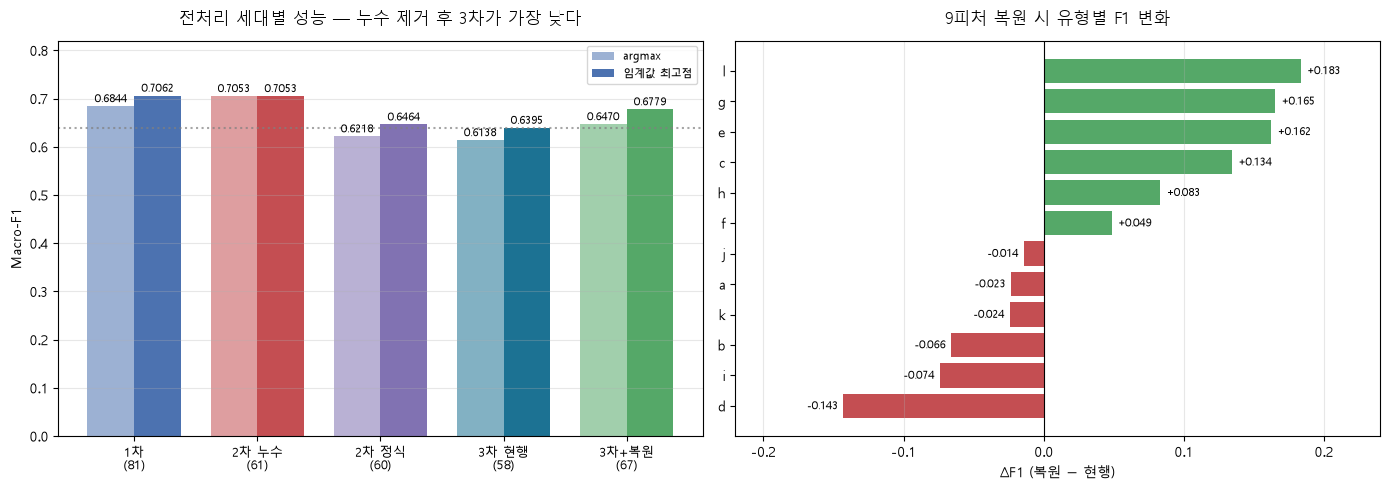

In [ ]:
import matplotlib
matplotlib.rcParams["font.family"] = ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

names = ["1차\n(81)", "2차 누수\n(61)", "2차 정식\n(60)", "3차 현행\n(58)", "3차+복원\n(67)"]
argm  = [res["1차"]["macro"], res["2차_누수"]["macro"], res["2차_정식"]["macro"],
         res["3차"]["macro"], rs[3]["argmax"]]
bestm = [res["1차"]["best_macro"], res["2차_누수"]["best_macro"], res["2차_정식"]["best_macro"],
         res["3차"]["best_macro"], rs[3]["best"]]
x = np.arange(len(names)); w = 0.38
colors = ["#4C72B0", "#C44E52", "#8172B2", "#1C7293", "#55A868"]
b1 = ax1.bar(x - w/2, argm, w, label="argmax", color=colors, alpha=.55)
b2 = ax1.bar(x + w/2, bestm, w, label="임계값 최고점", color=colors)
for bars, vals in ((b1, argm), (b2, bestm)):
    for r_, v in zip(bars, vals):
        ax1.text(r_.get_x() + r_.get_width()/2, v + .008, f"{v:.4f}", ha="center", fontsize=8)
ax1.set_xticks(x); ax1.set_xticklabels(names, fontsize=9)
ax1.set_ylim(0, .82); ax1.set_ylabel("Macro-F1"); ax1.legend(fontsize=8)
ax1.axhline(res["3차"]["best_macro"], ls=":", color="gray", alpha=.7)
ax1.set_title("전처리 세대별 성능 — 누수 제거 후 3차가 가장 낮다", pad=12)
ax1.grid(axis="y", alpha=.3)

dd2 = dd[dd["유형"] != "m"].sort_values("Δ")
cs_ = ["#C44E52" if v < 0 else "#55A868" for v in dd2["Δ"]]
ax2.barh(dd2["유형"], dd2["Δ"], color=cs_)
for i, (yv, v) in enumerate(zip(dd2["유형"], dd2["Δ"])):
    ax2.text(v + (0.004 if v >= 0 else -0.004), i, f"{v:+.3f}",
             va="center", ha="left" if v >= 0 else "right", fontsize=8)
ax2.axvline(0, color="black", lw=.8)
ax2.set_xlim(-0.22, 0.24); ax2.set_xlabel("ΔF1 (복원 − 현행)")
ax2.set_title("9피처 복원 시 유형별 F1 변화", pad=12)
ax2.grid(axis="x", alpha=.3)
plt.tight_layout(); plt.show()

### 복원 결과

| 구성 | 피처 | argmax | 최고 Macro-F1 | Δ최고 |
|---|---|---|---|---|
| 3차 현행 | 58 | 0.6138 | 0.6395 | — |
| + 날짜차 파생 | 62 | 0.6210 | 0.6575 | **+0.0180** |
| + 위협 집계 | 63 | 0.6488 | 0.6669 | **+0.0274** |
| **+ 둘 다** | **67** | 0.6470 | **0.6779** | **+0.0384** |

**가장 중요한 것은 유형별 변화입니다.**

| 유형 | 현행 F1 | 복원 후 | Δ |
|---|---|---|---|
| **`l`** | **0.0833** | **0.2667** | **+0.1834** |
| `g` | 0.4000 | 0.5652 | +0.1652 |
| `e` | 0.5333 | 0.6957 | +0.1624 |
| `c` | 0.3784 | 0.5128 | +0.1344 |
| `d` | 0.3429 | 0.2000 | −0.1429 |

> **`l` 유형은 발표자료가 '다음 과제 최우선'으로 지목한 유형입니다** (Recall 0.048 · 사실상 탐지 실패).
> 확신도 '낮음' 4개 중 **`l` · `g` · `c` 세 개가 크게 개선**됩니다.
> 대신 `d` 가 −0.14 로 악화되므로, **전면 채택이 아니라 유형별 득실을 따져야 합니다.**

### ⚠️ 이 수치를 인용할 때 주의할 것

이 절제·복원 실험은 **valid 홀드아웃에서 여러 구성을 비교해 고른 것**입니다.
따라서 `+0.0384` 에는 **valid 에 대한 선택 편향이 섞여 있습니다.**
실제로 채택하려면 별도 테스트셋 또는 교차검증으로 재확인해야 합니다.

즉 이 노트북의 결론은 *"이만큼 오른다"* 가 아니라
**"3차에서 빠진 9피처가 실질 신호였고, 되살릴 가치가 있다"** 입니다.

## 5. 사라진 9피처의 생성 공식 역산

복원하려면 공식이 필요합니다. 1차 전처리 코드가 없으므로
**원본 `train.csv` 와 1차 parquet 을 대조해 공식을 역산**합니다.

1차 X 의 인덱스가 원본 행 번호를 보존하므로 (`[2, 3, 4, …]` — 앞 2행 드롭) 정렬이 가능합니다.

In [ ]:
raw = pd.read_csv(f"{DATA}/train.csv", encoding="utf-8-sig")
X1raw = pd.read_parquet(f"{DATA}/구구 X_tr.parquet")
r = raw.loc[X1raw.index].copy()
print(f"원본 {raw.shape} → 1차 인덱스로 정렬 {r.shape}  (앞 {raw.shape[0]-r.shape[0]}행 드롭됨)")

for cdt in ["Transaction_Datetime", "Account_creation_datetime", "Last_atm_transaction_datetime",
            "Last_bank_branch_transaction_datetime", "Transaction_resumed_date"]:
    r[cdt] = pd.to_datetime(r[cdt], errors="coerce")

def match(series, target, name, formula):
    aa = pd.Series(np.asarray(series, dtype="float64"), index=target.index)
    bb = pd.Series(np.asarray(target, dtype="float64"), index=target.index)
    ok = (np.isclose(aa, bb, rtol=1e-6, atol=1e-6) | (aa.isna() & bb.isna())).mean() * 100
    print(f"  {'✅' if ok >= 99.9 else '❌'} {name:30s} {ok:6.2f}%   {formula}")
    return ok

print("\n[① 날짜차 파생 4종]  후보: .dt.days  vs  .total_seconds()/86400")
pairs = {"account_age_days": "Account_creation_datetime",
         "days_since_last_atm": "Last_atm_transaction_datetime",
         "days_since_last_branch": "Last_bank_branch_transaction_datetime",
         "days_since_resumed": "Transaction_resumed_date"}
for col, other in pairs.items():
    dt = r["Transaction_Datetime"] - r[other]
    match(dt.dt.days, X1raw[col], col, ".dt.days (정수 절사)")
    match(dt.dt.total_seconds()/86400, X1raw[col], "", ".total_seconds()/86400 (실수)")
    print()

print("[② 위협 집계 5종]")
AUTH = [f"Customer_flag_change_of_authentication_{i}" for i in range(1, 5)]
MAL  = [f"Customer_flag_terminal_malicious_behavior_{i}" for i in range(1, 7)]
NET  = ["Customer_rooting_jailbreak_indicator", "Customer_VPN_Indicator",
        "Customer_mobile_roaming_indicator", "Unused_terminal_status"]
match(r[AUTH].sum(axis=1), X1raw["auth_change_count"], "auth_change_count", "인증변경 4종 합")
match(r[MAL].sum(axis=1),  X1raw["terminal_malicious_count"], "terminal_malicious_count", "단말악성 6종 합")
match(r[NET].sum(axis=1),  X1raw["device_network_risk_count"], "device_network_risk_count",
      "루팅 + VPN + 로밍 + 미사용단말")
match(r[MAL+AUTH+NET].sum(axis=1), X1raw["threat_total_count"], "threat_total_count",
      "단말악성6 + 인증변경4 + 루팅·VPN·로밍·미사용단말 (6그룹)")
match(r["First_time_iOS_by_vulnerable_user"], X1raw["cert_or_auth_risk"], "cert_or_auth_risk",
      "First_time_iOS_by_vulnerable_user 를 그대로 복사 ⚠ 이름과 내용 불일치")

원본 (120000, 64) → 1차 인덱스로 정렬 (96140, 64)  (앞 23860행 드롭됨)

[① 날짜차 파생 4종]  후보: .dt.days  vs  .total_seconds()/86400
  ❌ account_age_days                 0.49%   .dt.days (정수 절사)
  ✅                                100.00%   .total_seconds()/86400 (실수)

  ❌ days_since_last_atm              0.02%   .dt.days (정수 절사)
  ✅                                100.00%   .total_seconds()/86400 (실수)

  ❌ days_since_last_branch           0.02%   .dt.days (정수 절사)
  ✅                                100.00%   .total_seconds()/86400 (실수)

  ❌ days_since_resumed               3.81%   .dt.days (정수 절사)
  ✅                                100.00%   .total_seconds()/86400 (실수)

[② 위협 집계 5종]
  ✅ auth_change_count              100.00%   인증변경 4종 합
  ✅ terminal_malicious_count       100.00%   단말악성 6종 합
  ✅ device_network_risk_count      100.00%   루팅 + VPN + 로밍 + 미사용단말
  ✅ threat_total_count             100.00%   단말악성6 + 인증변경4 + 루팅·VPN·로밍·미사용단말 (6그룹)
  ✅ cert_or_auth_risk              100.00%   First_time_iOS_by_vulner

### 역산 결과 — 9/9 전부 100% 확정

```python
# ── 날짜차 파생 4종 (실수 단위. .dt.days 로 절사하면 안 된다) ──
dt = lambda c: (df["Transaction_Datetime"] - df[c]).dt.total_seconds() / 86400
df["account_age_days"]       = dt("Account_creation_datetime")
df["days_since_last_atm"]    = dt("Last_atm_transaction_datetime")
df["days_since_last_branch"] = dt("Last_bank_branch_transaction_datetime")
df["days_since_resumed"]     = dt("Transaction_resumed_date")

# ── 위협 집계 5종 ──
AUTH = [f"Customer_flag_change_of_authentication_{i}"      for i in range(1, 5)]
MAL  = [f"Customer_flag_terminal_malicious_behavior_{i}"   for i in range(1, 7)]
NET  = ["Customer_rooting_jailbreak_indicator", "Customer_VPN_Indicator",
        "Customer_mobile_roaming_indicator",    "Unused_terminal_status"]

df["auth_change_count"]         = df[AUTH].sum(axis=1)
df["terminal_malicious_count"]  = df[MAL].sum(axis=1)
df["device_network_risk_count"] = df[NET].sum(axis=1)
df["threat_total_count"]        = df[MAL + AUTH + NET].sum(axis=1)
df["cert_or_auth_risk"]         = df["First_time_iOS_by_vulnerable_user"]   # ⚠ 아래 주의
```

**주의 2가지**

1. **날짜차는 `.dt.days` 가 아니라 `.total_seconds()/86400` 입니다.**
   정수 절사 버전은 일치율이 **0.02~3.8%** 로 완전히 다릅니다.
   시·분 단위 소수점이 실제 신호를 담고 있습니다.

2. **`cert_or_auth_risk` 는 이름과 내용이 다릅니다.**
   "인증서/인증 위험"이라는 이름과 달리 실제 값은 `First_time_iOS_by_vulnerable_user`
   플래그를 그대로 복사한 것입니다 (96,140행 중 **23행만 1**, 0.024%).
   1차 전처리 단계에서 대입 실수가 있었던 것으로 보이며,
   → [`docs/03a` #A-18](../../docs/03a_issues_data_modeling.md#a-18)

## 6. 결론

### 시간순으로 복원한 전처리 이력

| 세대 | 피처 | argmax | 최고 | 무슨 일이 있었나 |
|---|---|---|---|---|
| **1차** | 81 | 0.6844 | 0.7062 | 빈도 인코딩 · 날짜차 · 위협 집계 포함. **누수 없음** |
| **2차** | 61 | 0.7053 | 0.7053 | 33개 제거 + 13개 추가 재설계. **`is_fraud` 누수 유입** → 중간보고 0.7103 |
| 2차 정식 | 60 | 0.6218 | 0.6464 | 누수 제거 후 정식 수치 (`reports/13` 의 0.646) |
| **3차** | 58 | **0.6138** | **0.6395** | `Is_dawn`·`weak_signal_composite_score` 추가 제거. **현행 운영 모델** |
| (제안) | 67 | 0.6470 | **0.6779** | 3차 + 날짜차 4 + 위협 집계 5 복원 |

### 팀이 잘한 것

- **`is_fraud` 누수를 스스로 찾아 제거했습니다.** 성능이 0.7053 → 0.6218 로 떨어지는 수정입니다.
- **빈도 인코딩(`*_freq`)과 `Location_sigungu` 를 뺀 것은 옳았습니다.** 실측으로 노이즈였습니다 (+0.006 · +0.010).
- **`weak_signal_composite_score` 를 뺀 것도 옳았습니다.** 그 피처는 `_composite_cols` 미정의로 재현이 불가능했습니다.

### 놓친 것

- **날짜차 파생 4종과 위협 집계 5종이 함께 사라졌습니다.** 이 둘은 노이즈가 아니라 실질 신호였고,
  합계 −0.07 의 손실을 냈습니다. 1차 → 2차 재설계 과정에서 의도적으로 뺀 것인지
  누락된 것인지는 기록이 남아 있지 않습니다.

### 다음에 할 일

1. 위 9개 공식을 **3차 전처리 파이프라인에 추가**해 67피처로 재학습
2. **별도 홀드아웃**으로 `+0.0384` 를 재확인 (이 노트북 수치는 valid 선택 편향 포함)
3. `d` 유형이 −0.14 악화되므로 **유형별 득실 확인** 후 채택 여부 결정
4. `cert_or_auth_risk` 는 이름대로 재정의하거나 제외

> 관련 문서: [`docs/09_reconstruction_log.md`](../../docs/09_reconstruction_log.md) ·
> [`docs/03a` #A-17](../../docs/03a_issues_data_modeling.md#a-17)